In [ ]:
#import libraries
import pandas as pd
from sklearn.metrics import roc_auc_score, log_loss    
#roc_auc_score → to evaluate how well the model ranks converters
#log_loss → to evaluate the quality of the predicted probabilities

In [2]:
#load targeting test dataset
test_final = pd.read_parquet(
    "../../data/samples/customer_targeting_test_final.parquet"
)

print("Rows:", len(test_final))
print("Columns:", test_final.columns.tolist())

Rows: 8420
Columns: ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'treatment', 'conversion', 'visit', 'exposure', 'p_treatment', 'p_control', 'uplift', 'uplift_decile']


In [3]:
#Treatment model ROC-AUC
treatment_test = test_final[test_final["treatment"] == 1]

treatment_auc = roc_auc_score(
    treatment_test["conversion"],
    treatment_test["p_treatment"]
)

print(f"Treatment test ROC-AUC: {treatment_auc:.4f}")

Treatment test ROC-AUC: 0.9468


In [4]:
#control model ROU-AUC
control_test = test_final[test_final["treatment"] == 0]

control_auc = roc_auc_score(
    control_test["conversion"],
    control_test["p_control"]
)

print(f"Control test ROC-AUC: {control_auc:.4f}")

Control test ROC-AUC: 0.9400


In [5]:
#add log loss
from sklearn.metrics import log_loss

treatment_logloss = log_loss(
    treatment_test["conversion"],
    treatment_test["p_treatment"]
)

control_logloss = log_loss(
    control_test["conversion"],
    control_test["p_control"]
)

print(f"Treatment Log Loss: {treatment_logloss:.6f}")
print(f"Control Log Loss:   {control_logloss:.6f}")

Treatment Log Loss: 0.014145
Control Log Loss:   0.008812


**Log Loss Interpretation**

The treatment model achieves a Log Loss of **0.014145**, while the control model achieves a lower Log Loss of **0.008812**. Since lower Log Loss indicates better probabilistic predictions, the control model provides more accurate probability estimates on the test set. Log Loss penalizes confident incorrect predictions more heavily, making it useful for evaluating the quality of predicted probabilities.

However, because conversion is a very rare outcome in the dataset, the absolute Log Loss values should not be interpreted in isolation. The ROC-AUC results provide a clearer assessment of the models' ability to **rank customers by their likelihood of conversion**.

**Why No Confusion Matrix?**

A confusion matrix is not used as the primary evaluation here because conversion is an extremely rare outcome. With such class imbalance, using a default classification threshold such as **0.5** would classify nearly all customers as non-converters, providing limited insight into the model's ability to distinguish potential converters.

ROC-AUC is more appropriate for this evaluation because it measures the model's ability to **rank converters above non-converters across different classification thresholds**, without requiring a single arbitrary threshold.


In [6]:
#Verify the evaluation outputs
evaluation_summary = pd.DataFrame({
    "Model": ["Treatment", "Control"],
    "ROC_AUC": [treatment_auc, control_auc],
    "Log_Loss": [treatment_logloss, control_logloss]
})

evaluation_summary

,Model,ROC_AUC,Log_Loss
0,Treatment,0.946775,0.014145
1,Control,0.940009,0.008812


In [7]:
#save the evaluation summary
evaluation_summary.to_csv(
    "../../outputs/tables/customer_targeting_model_evaluation.csv",
    index=False
)

print("Evaluation summary saved successfully.")

Evaluation summary saved successfully.


#### Overall Model Evaluation

The treatment and control response models show strong predictive performance on the held-out test set, with ROC-AUC values of **0.9468** and **0.9400**, respectively. The corresponding Log Loss values are **0.014145** for treatment and **0.008812** for control.

However, these metrics evaluate **within-group conversion prediction**, not incremental treatment response. A customer may have a high probability of conversion under both treatment and control, while receiving little additional benefit from the offer. Therefore, strong ROC-AUC and Log Loss performance does not necessarily imply strong uplift-ranking performance.

This distinction is important for the T-Learner because uplift is estimated as the difference between two independently predicted probabilities:

$$
\text{Uplift} = p_{\text{treatment}} - p_{\text{control}}
$$

As a result, strong performance of the individual treatment and control models does not guarantee that their difference will reliably identify customers who are most responsive to treatment. This is consistent with the non-monotonic uplift patterns observed in the decile evaluation.

**Caveat:** The results should be interpreted cautiously because the training and test sets contain relatively few positive conversion examples. The test set contains approximately **13 treatment conversions and 7 control conversions**, so the observed AUC values may be sensitive to sampling variability. Validation using a larger test sample or repeated resampling would provide greater confidence in the generalizability of the results.


In [8]:
#Sort customers and create four targeting groups
#"If we can only target some customers with the offer, which customers should we target first?"

# Sort customers by predicted uplift, highest first
test_targeting = test_final.sort_values(
    "uplift",
    ascending=False  #Sort from largest to smallest:Target customers with the highest predicted incremental benefit first.
).copy()

# Number of customers
n = len(test_targeting)

# Create targeting groups based on population percentile
# Divide the sorted customers into four groups based on their position in the ranking.
test_targeting["targeting_group"] = pd.cut(
    range(n),
    bins=[
        -1,
        int(0.10 * n + 0.999999) - 1,
        int(0.25 * n + 0.999999) - 1,
        int(0.50 * n + 0.999999) - 1,
        n - 1
    ],
    labels=[
        "Top 10%",
        "10-25%",
        "25-50%",
        "Bottom 50%"
    ]
)

# Check the resulting groups
test_targeting["targeting_group"].value_counts(sort=False)

targeting_group
Top 10%        842
10-25%        1263
25-50%        2105
Bottom 50%    4210
Name: count, dtype: int64

In [9]:
#verify population percentage
group_counts = (
    test_targeting
    .groupby("targeting_group", observed=False)
    .size()
    .reset_index(name="N")
)

group_counts["Population %"] = (
    group_counts["N"] / len(test_targeting) * 100
)

group_counts

,targeting_group,N,Population %
0,Top 10%,842,10.0
1,10-25%,1263,15.0
2,25-50%,2105,25.0
3,Bottom 50%,4210,50.0


In [10]:
#calculate predicted uplift
predicted_uplift = (
    test_targeting
    .groupby("targeting_group", observed=False)["uplift"]
    .mean()
    .reset_index(name="Predicted Uplift")
)

predicted_uplift

,targeting_group,Predicted Uplift
0,Top 10%,0.007212
1,10-25%,0.000951
2,25-50%,0.000508
3,Bottom 50%,0.000238


In [11]:
#calculate observed uplift
test_targeting.columns.tolist()

['f0',
 'f1',
 'f2',
 'f3',
 'f4',
 'f5',
 'f6',
 'f7',
 'f8',
 'f9',
 'f10',
 'f11',
 'treatment',
 'conversion',
 'visit',
 'exposure',
 'p_treatment',
 'p_control',
 'uplift',
 'uplift_decile',
 'targeting_group']

In [ ]:
# Calculate observed uplift by targeting group

observed_uplift = (
    test_targeting
    .groupby("targeting_group", observed=False)
    .apply(
        lambda g: pd.Series({
            "Treatment Conversion Rate": (
                g.loc[g["treatment"] == 1, "conversion"].mean()
            ),
            "Control Conversion Rate": (
                g.loc[g["treatment"] == 0, "conversion"].mean()
            )
        })
    )
    .reset_index()
)

observed_uplift["Observed Uplift"] = (
    observed_uplift["Treatment Conversion Rate"]
    - observed_uplift["Control Conversion Rate"]
)

observed_uplift

,targeting_group,Treatment Conversion Rate,Control Conversion Rate,Observed Uplift
0,Top 10%,0.018141,0.012469,0.005672
1,10-25%,0.001548,0.001621,-0.000073
2,25-50%,0.000937,0.000963,-0.000026
3,Bottom 50%,0.001459,0.000000,0.001459


In [13]:
#final summary table
group_summary = (
    group_counts
    .merge(predicted_uplift, on="targeting_group")
    .merge(
        observed_uplift[
            ["targeting_group", "Observed Uplift"]
        ],
        on="targeting_group"
    )
)

group_summary = group_summary.rename(
    columns={"targeting_group": "Group"}
)

group_summary = group_summary[
    [
        "Group",
        "Population %",
        "Predicted Uplift",
        "Observed Uplift",
        "N"
    ]
]

group_summary.style.format({
    "Population %": "{:.1f}%",
    "Predicted Uplift": "{:.4f}",
    "Observed Uplift": "{:.4f}",
    "N": "{:,}"
})

,Group,Population %,Predicted Uplift,Observed Uplift,N
0,Top 10%,10.0%,0.0072,0.0057,842
1,10-25%,15.0%,0.0010,-0.0001,"1,263"
2,25-50%,25.0%,0.0005,-0.0000,"2,105"
3,Bottom 50%,50.0%,0.0002,0.0015,"4,210"


#### Customer-Level Incremental Response

The customer-level targeting analysis shows that the **Top 10%** of customers ranked by predicted uplift has substantially higher observed incremental response than the **Bottom 50%**. The Top 10% achieves an observed uplift of **0.0057 (0.57 percentage points)**, compared with **0.0015 (0.15 percentage points)** for the Bottom 50%, representing approximately **3.8× higher observed uplift**. This supports the use of predicted uplift to prioritize customers who are more likely to benefit incrementally from treatment.

However, the observed uplift is **not monotonic across all four targeting groups**. The 10–25% group has slightly negative uplift (**−0.0001**), while the 25–50% group is approximately zero (**−0.0000**). The Bottom 50% is again positive at **0.0015**. Therefore, the results do not support a perfectly ordered uplift ranking across the entire population.

The strongest evidence is that the **highest-uplift segment, particularly the Top 10%, captures substantially greater incremental response**. The wider targeting groups provide larger sample sizes than individual deciles, reducing some sampling noise, but the non-monotonic pattern indicates that the model's uplift estimates should still be interpreted cautiously.


In [14]:
# Build comparison groups
# "Is our model actually doing better than simply targeting customers randomly?"

# Random-targeting baseline:
# observed uplift across the full test set
random_treatment_rate = (
    test_targeting.loc[
        test_targeting["treatment"] == 1,
        "conversion"
    ].mean()
)

random_control_rate = (
    test_targeting.loc[
        test_targeting["treatment"] == 0,
        "conversion"
    ].mean()
)

random_observed_uplift = (
    random_treatment_rate - random_control_rate
)

print("Random baseline observed uplift:", random_observed_uplift)

Random baseline observed uplift: 0.0014251781472684087


In [ ]:
#Calculate cumulative targeting scenarios
#If we target only the customers with the highest predicted uplift, how much incremental response do we actually get?

cumulative_cuts = [0.10, 0.20, 0.30]        #"What happens if I have enough budget to target the top 10%, 20%, or 30%?"

cumulative_results = []

for cut in cumulative_cuts:

    # Number of customers in the cumulative targeting group
    cutoff_n = int(cut * len(test_targeting))

    group = test_targeting.iloc[:cutoff_n]

    # Treatment conversion rate
    treatment_rate = (
        group.loc[
            group["treatment"] == 1,
            "conversion"
        ].mean()
    )

    # Control conversion rate
    control_rate = (
        group.loc[
            group["treatment"] == 0,
            "conversion"
        ].mean()
    )

    # Observed uplift
    observed_uplift = treatment_rate - control_rate

    cumulative_results.append({
        "Target Group": f"Top {int(cut * 100)}%",
        "Population %": cut * 100,
        "Observed Lift": observed_uplift,
        "N": len(group)
    })

cumulative_results = pd.DataFrame(cumulative_results)

cumulative_results

,Target Group,Population %,Observed Lift,N
0,Top 10%,10.0,0.005672,842
1,Top 20%,20.0,0.002765,1684
2,Top 30%,30.0,0.001223,2526


Evaluated cumulative targeting scenarios by taking the highest-ranked customers according to predicted uplift and measuring the observed treatment-control difference among the Top 10%, Top 20%, and Top 30%. This helps assess how the model performs under different targeting budgets or population coverage levels.

In [ ]:
#Build cumulative uplift curve
#"If I target everyone up to this point, what incremental uplift have I actually achieved?" that's a cumulative uplift curve.

curve_data = test_targeting.reset_index(drop=True).copy()

# Running number of customers targeted
curve_data["targeted_n"] = range(1, len(curve_data) + 1)

# Percentage of population targeted
curve_data["population_pct"] = (
    curve_data["targeted_n"] / len(curve_data) * 100
)

# Identify treatment and control customers
curve_data["is_treatment"] = (
    curve_data["treatment"] == 1
)

curve_data["is_control"] = (
    curve_data["treatment"] == 0
)

# Cumulative treatment/control populations
curve_data["cumulative_treatment_n"] = (       #As we move down the uplift ranking, how many treatment customers have we encountered so far?
    curve_data["is_treatment"].cumsum()
)

curve_data["cumulative_control_n"] = (
    curve_data["is_control"].cumsum()
)

# Cumulative treatment/control conversions
curve_data["cumulative_treatment_conversions"] = (          #Among the customers we've targeted so far, how many treatment customers actually converted?
    (
        curve_data["is_treatment"] &
        (curve_data["conversion"] == 1)
    ).cumsum()
)

curve_data["cumulative_control_conversions"] = (           #Among the customers encountered so far, how many control customers converted?
    (
        curve_data["is_control"] &
        (curve_data["conversion"] == 1)
    ).cumsum()
)

# Cumulative treatment conversion rate
curve_data["cumulative_treatment_rate"] = (
    curve_data["cumulative_treatment_conversions"]
    / curve_data["cumulative_treatment_n"]
)

# Cumulative control conversion rate
curve_data["cumulative_control_rate"] = (
    curve_data["cumulative_control_conversions"]
    / curve_data["cumulative_control_n"]
)

# Cumulative observed uplift
curve_data["cumulative_observed_uplift"] = (
    curve_data["cumulative_treatment_rate"]
    - curve_data["cumulative_control_rate"]
)

curve_data.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,population_pct,is_treatment,is_control,cumulative_treatment_n,cumulative_control_n,cumulative_treatment_conversions,cumulative_control_conversions,cumulative_treatment_rate,cumulative_control_rate,cumulative_observed_uplift
0,14.352055,10.679513,8.445316,-4.246166,13.738506,-2.960807,-22.411453,6.890503,3.710581,28.276981,...,0.011876,True,False,1,0,0,0,0.0,NaN,NaN
1,12.697316,10.059654,8.762348,-4.219653,14.439578,1.624218,-22.932665,10.781930,3.758827,13.190056,...,0.023753,False,True,1,1,0,0,0.0,0.0,0.0
2,18.808897,10.059654,8.762025,-1.291756,15.220767,4.115453,-15.908287,4.833815,3.759910,13.190056,...,0.035629,True,False,2,1,0,0,0.0,0.0,0.0
3,18.168735,10.059654,8.242676,-1.332715,13.429889,4.115453,-12.110436,4.833815,3.756040,38.403249,...,0.047506,False,True,2,2,0,0,0.0,0.0,0.0
4,14.373012,10.059654,8.215257,2.934780,14.002872,4.115453,-9.065248,4.833815,3.707721,49.130220,...,0.059382,True,False,3,2,0,0,0.0,0.0,0.0


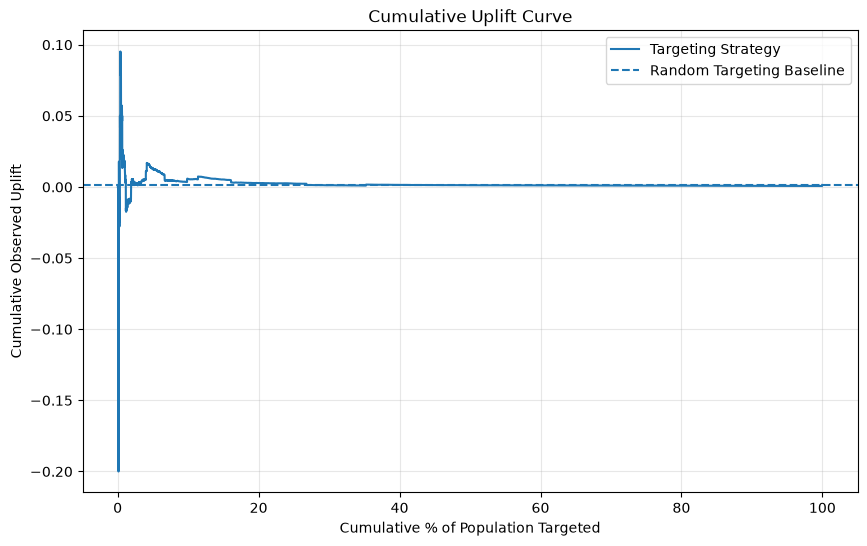

Random-targeting observed uplift: 0.001425


In [17]:
#Build and plot the corrected cumulative uplift curve

import matplotlib.pyplot as plt

# Random-targeting baseline
random_treatment_rate = (
    test_targeting.loc[
        test_targeting["treatment"] == 1,
        "conversion"
    ].mean()
)

random_control_rate = (
    test_targeting.loc[
        test_targeting["treatment"] == 0,
        "conversion"
    ].mean()
)

random_observed_uplift = (
    random_treatment_rate - random_control_rate
)

# Remove rows where cumulative uplift cannot yet be calculated
plot_data = curve_data.dropna(
    subset=["cumulative_observed_uplift"]
).copy()

plt.figure(figsize=(10, 6))

# Targeting curve
plt.plot(
    plot_data["population_pct"],
    plot_data["cumulative_observed_uplift"],
    label="Targeting Strategy"
)

# Random baseline: horizontal because this is an uplift rate
plt.axhline(
    y=random_observed_uplift,
    linestyle="--",
    label="Random Targeting Baseline"
)

plt.xlabel("Cumulative % of Population Targeted")
plt.ylabel("Cumulative Observed Uplift")
plt.title("Cumulative Uplift Curve")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

print(
    f"Random-targeting observed uplift: "
    f"{random_observed_uplift:.6f}"
)

In [18]:
#Build targeting recommendation table

recommendation_table = pd.DataFrame({
    "Target Group": [
        "Top 10%",
        "Top 20%",
        "Top 30%",
        "Random / Everyone"
    ],
    "Population %": [
        10.0,
        20.0,
        30.0,
        100.0
    ],
    "Observed Lift": [
        cumulative_results.loc[
            cumulative_results["Target Group"] == "Top 10%",
            "Observed Lift"
        ].iloc[0],

        cumulative_results.loc[
            cumulative_results["Target Group"] == "Top 20%",
            "Observed Lift"
        ].iloc[0],

        cumulative_results.loc[
            cumulative_results["Target Group"] == "Top 30%",
            "Observed Lift"
        ].iloc[0],

        random_observed_uplift
    ],
    "Recommended Action": [
        "Prioritize",
        "Consider if additional reach is required",
        "Limited targeting; incremental benefit is weaker",
        "No uplift-based prioritization"
    ]
})

recommendation_table

,Target Group,Population %,Observed Lift,Recommended Action
0,Top 10%,10.0,0.005672,Prioritize
1,Top 20%,20.0,0.002765,Consider if additional reach is required
2,Top 30%,30.0,0.001223,Limited targeting; incremental benefit is weaker
3,Random / Everyone,100.0,0.001425,No uplift-based prioritization


#### Evaluate the Targeting Strategy

The targeting analysis indicates that concentrating exposure on customers with the highest predicted uplift produces stronger observed incremental response than targeting the broader population. The **Top 10%** achieves an observed lift of **0.005672 (0.57 percentage points)**, while the **Top 20%** achieves **0.002765 (0.28 percentage points)**. Both exceed the full-test-set random-targeting baseline of **0.001425 (0.14 percentage points)**, with the strongest benefit concentrated among the highest-ranked customers.

The benefit decreases as the targeted population expands. The **Top 30%** achieves an observed lift of **0.001223 (0.12 percentage points)**, slightly below the random baseline. This suggests that the model's targeting value is concentrated primarily within the **Top 10–20%** rather than extending consistently across the broader population.

The cumulative uplift curve supports the same conclusion: the largest advantage occurs near the top of the predicted-uplift ranking and diminishes as additional customers are included. The fluctuations at the beginning of the curve should be interpreted cautiously because they are based on very small cumulative treatment and control groups.

Overall, the results support **prioritizing the Top 10% of customers** for targeted exposure. Expanding to the **Top 20%** may be reasonable when greater reach is required, while targeting the **Top 30% or more** provides little evidence of incremental benefit over random targeting. The model is therefore best viewed as a **precision targeting tool for the highest-uplift customers**, rather than evidence of a uniformly monotonic uplift ranking across the entire population.

The positive uplift observed in the Bottom 50% should also be interpreted cautiously, as it is driven by the **absence of control conversions in that group** and therefore may not represent a reliable estimate of incremental treatment response.
